In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv('../data/sales_train_validation.csv')
calendar = pd.read_csv('../data/calendar.csv')
prices = pd.read_csv('../data/sell_prices.csv')

In [3]:
# Look the structure
print('sales shape:', sales.shape)
print('calendar shape:', calendar.shape)
print('prices shape:', prices.shape)

sales shape: (30490, 1919)
calendar shape: (1969, 14)
prices shape: (6841121, 4)


***Sales File***

In [4]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [5]:
print(sales.columns.tolist())

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100', 'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', 'd_107', 'd_108', 'd_109', 'd_110', 'd_111', 'd_112', 'd_113', 'd_114', 'd_115', 'd_116', '

In [6]:
day_cols = [c for c in sales.columns if c.startswith('d_')]
zero_ratio = (sales[day_cols] == 0).sum().sum() / (sales.shape[0] * len(day_cols))
print(f'zero ratio: {zero_ratio:.2%}')

zero ratio: 68.20%


***Calendar File***

In [7]:
calendar.tail()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


In [8]:
print(calendar['event_name_1'].dropna().unique())

['SuperBowl' 'ValentinesDay' 'PresidentsDay' 'LentStart' 'LentWeek2'
 'StPatricksDay' 'Purim End' 'OrthodoxEaster' 'Pesach End' 'Cinco De Mayo'
 "Mother's day" 'MemorialDay' 'NBAFinalsStart' 'NBAFinalsEnd'
 "Father's day" 'IndependenceDay' 'Ramadan starts' 'Eid al-Fitr'
 'LaborDay' 'ColumbusDay' 'Halloween' 'EidAlAdha' 'VeteransDay'
 'Thanksgiving' 'Christmas' 'Chanukah End' 'NewYear' 'OrthodoxChristmas'
 'MartinLutherKingDay' 'Easter']


In [9]:
print(calendar['event_name_2'].dropna().unique())

['Easter' 'Cinco De Mayo' 'OrthodoxEaster' "Father's day"]


In [10]:
print('CA SNAP days:', calendar['snap_CA'].sum())
print('TX SNAP days:', calendar['snap_TX'].sum())
print('WI SNAP days:', calendar['snap_WI'].sum())

CA SNAP days: 650
TX SNAP days: 650
WI SNAP days: 650


***Price File***

In [11]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [12]:
prices['sell_price'].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

In [13]:
print('Items:', prices['item_id'].nunique())
print('Stores:', prices['store_id'].nunique())

Items: 3049
Stores: 10


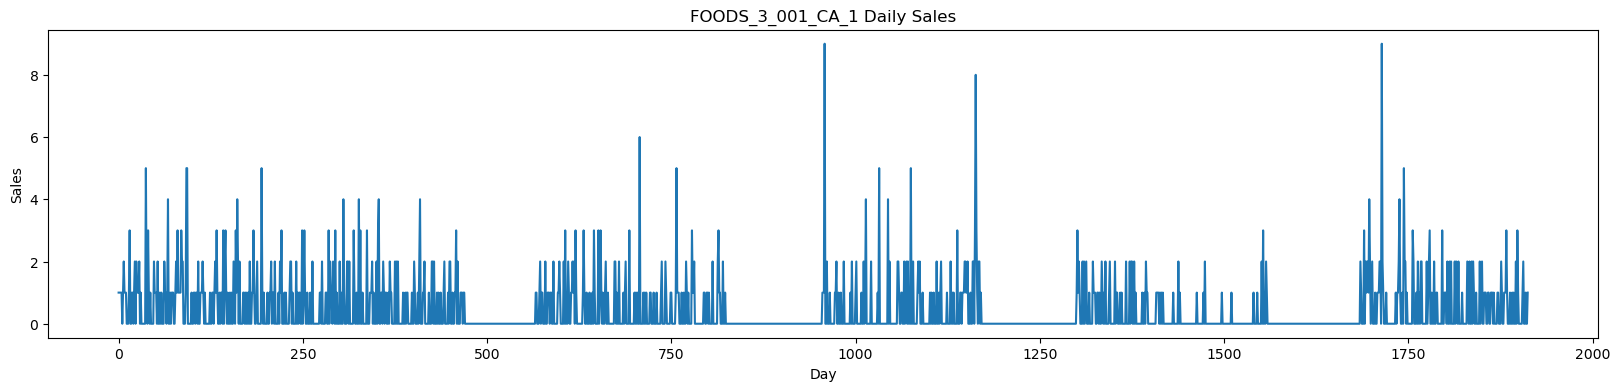

In [14]:
# A time siries plot for a random item
item = sales[sales['id'] == 'FOODS_3_001_CA_1_validation']
item_values = item[day_cols].values.flatten()

plt.figure(figsize=(20, 4))
plt.plot(item_values)
plt.title('FOODS_3_001_CA_1 Daily Sales')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.show()

***Average Sales by Weekday***

In [15]:
sales_melted = sales[['id'] + day_cols[:365]].melt(
    id_vars='id',
    var_name='d',
    value_name='sales'
)

In [16]:
sales_melted

,id,d,sales
0,HOBBIES_1_001_CA_1_validation,d_1,0
1,HOBBIES_1_002_CA_1_validation,d_1,0
2,HOBBIES_1_003_CA_1_validation,d_1,0
3,HOBBIES_1_004_CA_1_validation,d_1,0
4,HOBBIES_1_005_CA_1_validation,d_1,0
...,...,...,...
11128845,FOODS_3_823_WI_3_validation,d_365,0
11128846,FOODS_3_824_WI_3_validation,d_365,0
11128847,FOODS_3_825_WI_3_validation,d_365,1
11128848,FOODS_3_826_WI_3_validation,d_365,0


In [17]:
sales_melted = sales_melted.merge(calendar[['d', 'weekday']], on='d')

In [18]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly = sales_melted.groupby('weekday')['sales'].mean()
weekly = weekly.reindex(weekday_order)
print(weekly)

weekday
Monday       0.828031
Tuesday      0.772496
Wednesday    0.758725
Thursday     0.768813
Friday       0.881390
Saturday     1.059673
Sunday       1.007114
Name: sales, dtype: float64


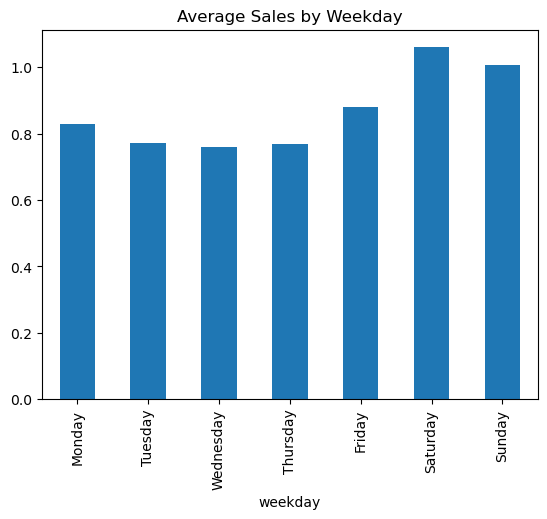

In [19]:
weekly.plot(kind='bar', title='Average Sales by Weekday')
plt.show()

***Sales Across Level***

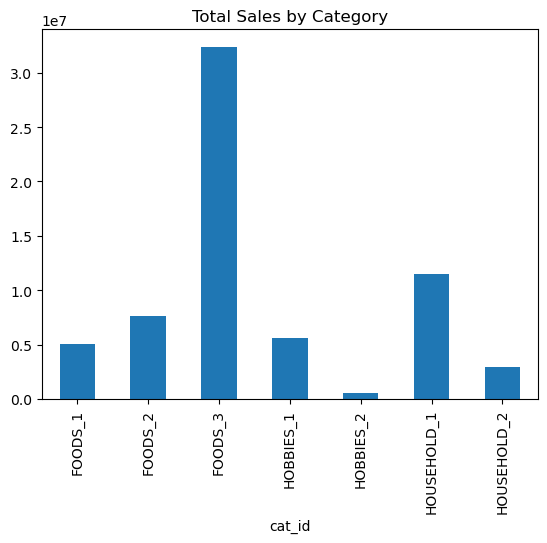

In [20]:
sales['cat_id'] = sales['id'].str.split('_').str[:2].str.join('_')

category_sales = sales.groupby('cat_id')[day_cols].sum().sum(axis=1)
category_sales.plot(kind='bar', title='Total Sales by Category')
plt.show()

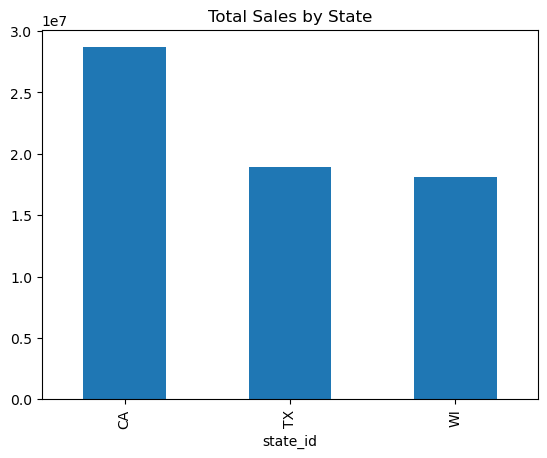

In [21]:
sales['state_id'] = sales['id'].str.split('_').str[3]
state_sales = sales.groupby('state_id')[day_cols].sum().sum(axis=1)
state_sales.plot(kind='bar', title='Total Sales by State')
plt.show()

In [22]:
zero_ratio = (sales[day_cols] == 0).sum().sum() / (sales.shape[0] * len(day_cols))
print(f'Zero ratio: {zero_ratio:.2%}')

# High zero ratio. Should use Tweedie loss for loss function rather than RMSE loss

Zero ratio: 68.20%


In [23]:
# combine calendar to see the SNAP effecct on sales. We will only look at CA for simplicity
sales_melted = sales[['id'] + day_cols].melt(
    id_vars='id', var_name='d', value_name='sales'
)
sales_melted = sales_melted.merge(
    calendar[['d', 'snap_CA', 'snap_TX', 'snap_WI']], on='d'
)


ca_foods = sales_melted[sales_melted['id'].str.contains('FOODS') & 
                         sales_melted['id'].str.contains('CA')]

print(ca_foods.groupby('snap_CA')['sales'].mean())

snap_CA
0    1.688498
1    1.862391
Name: sales, dtype: float64


SNAP has effect on the sales
--> snap_CA/snap_TX/snap_WI  

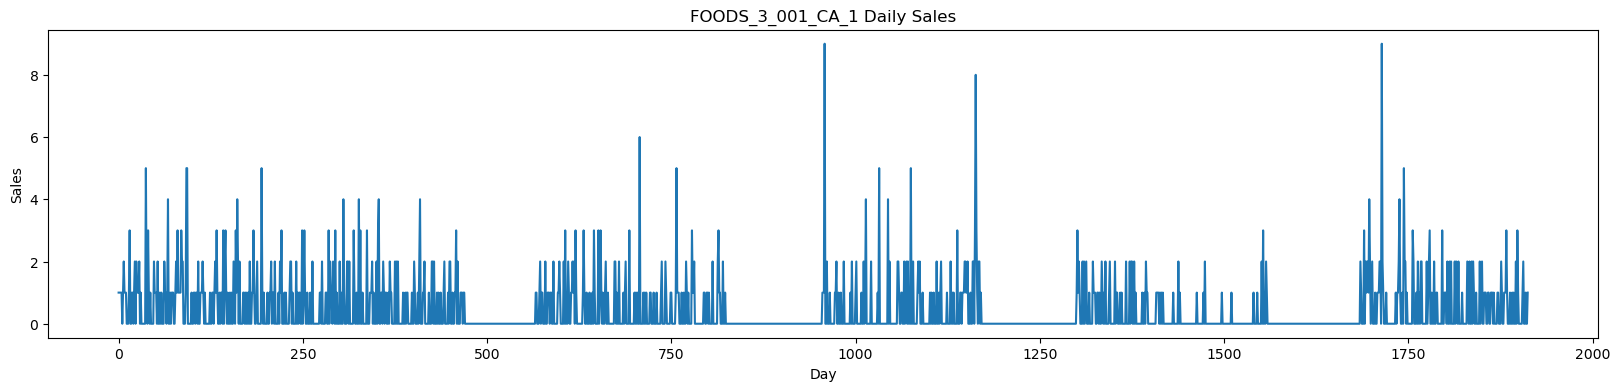

In [25]:
# Choose a random item of highest sales category and plot its sales over time
item = sales[sales['id'] == 'FOODS_3_001_CA_1_validation']
item_values = item[day_cols].values.flatten()

plt.figure(figsize=(20, 4))
plt.plot(item_values)
plt.title('FOODS_3_001_CA_1 Daily Sales')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.show()

In [26]:
# Effect of events on sales. We will only look at the first event for simplicity.
sales_melted = sales[['id'] + day_cols].melt(
    id_vars='id', var_name='d', value_name='sales'
)
sales_melted = sales_melted.merge(
    calendar[['d', 'event_name_1']], on='d'
)

sales_melted['has_event'] = sales_melted['event_name_1'].notna().astype(int)
print(sales_melted.groupby('has_event')['sales'].mean())


event_sales = sales_melted.groupby('event_name_1')['sales'].mean().sort_values(ascending=False)
print(event_sales.head(10))

has_event
0    1.131165
1    1.071012
Name: sales, dtype: float64
event_name_1
LaborDay          1.382571
SuperBowl         1.342211
Easter            1.296084
OrthodoxEaster    1.255395
Father's day      1.199147
Purim End         1.179305
Eid al-Fitr       1.156694
ColumbusDay       1.153322
VeteransDay       1.151814
Ramadan starts    1.140689
Name: sales, dtype: float64


Price vs Sales correlation:
            sell_price    sales
sell_price     1.00000 -0.15092
sales         -0.15092  1.00000

Average sales by price range:


/var/folders/x9/fhf6q7xd0wjgg_92l4b1sykm0000gn/T/ipykernel_1868/3548252268.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sales_melted.groupby('price_bin')['sales'].mean())


price_bin
very low     3.298363
low          1.302448
mid          1.158062
high         0.763114
very high    0.588162
Name: sales, dtype: float64


/var/folders/x9/fhf6q7xd0wjgg_92l4b1sykm0000gn/T/ipykernel_1868/3548252268.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_melted.groupby('price_bin')['sales'].mean().plot(


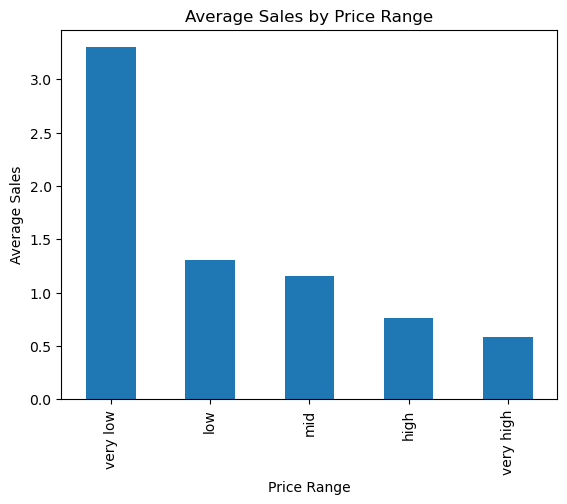

In [27]:
# Effect of price on sales. We will only look at the first 365 days for simplicity. 
sales_melted = sales[['id', 'item_id', 'store_id'] + day_cols].melt(
    id_vars=['id', 'item_id', 'store_id'],
    var_name='d',
    value_name='sales'
)

sales_melted = sales_melted.merge(calendar[['d', 'wm_yr_wk']], on='d')

sales_melted = sales_melted.merge(prices, on=['item_id', 'store_id', 'wm_yr_wk'], how='left')

print('Price vs Sales correlation:')
print(sales_melted[['sell_price', 'sales']].corr())


sales_melted['price_bin'] = pd.qcut(sales_melted['sell_price'], q=5, labels=['very low', 'low', 'mid', 'high', 'very high'])
print('\nAverage sales by price range:')
print(sales_melted.groupby('price_bin')['sales'].mean())


sales_melted.groupby('price_bin')['sales'].mean().plot(
    kind='bar',
    title='Average Sales by Price Range'
)
plt.xlabel('Price Range')
plt.ylabel('Average Sales')
plt.show()

In [28]:
# The zero ratio by category.
sales['cat_id'] = sales['id'].str.split('_').str[:2].str.join('_')

for cat in sales['cat_id'].unique():
    cat_data = sales[sales['cat_id'] == cat][day_cols]
    zero_ratio = (cat_data == 0).sum().sum() / cat_data.size
    print(f'{cat}: {zero_ratio:.2%}')

HOBBIES_1: 73.27%
HOBBIES_2: 88.48%
HOUSEHOLD_1: 63.11%
HOUSEHOLD_2: 80.72%
FOODS_1: 63.20%
FOODS_2: 68.07%
FOODS_3: 58.79%


Jan    1.109621
Feb    1.136262
Mar    1.126266
Apr    1.123604
May    1.066050
Jun    1.147964
Jul    1.151932
Aug    1.178965
Sep    1.163636
Oct    1.138520
Nov    1.091861
Dec    1.081681
Name: sales, dtype: float64


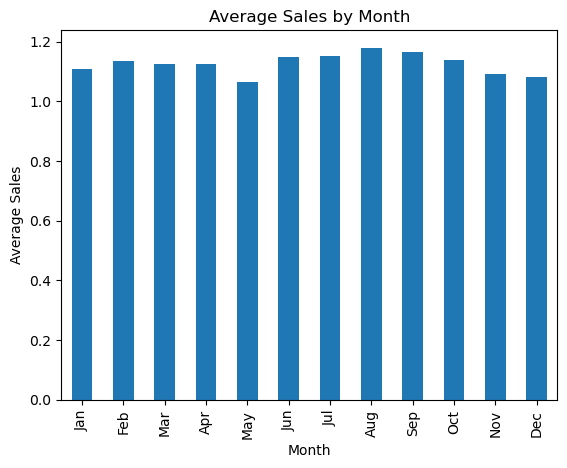

In [29]:
# Compare the sales across months. 
sales_melted = sales[['id'] + day_cols].melt(
    id_vars='id', var_name='d', value_name='sales'
)
sales_melted = sales_melted.merge(calendar[['d', 'month', 'year']], on='d')


monthly = sales_melted.groupby('month')['sales'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly.index = month_names

print(monthly)

# 畫圖
monthly.plot(kind='bar', title='Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()